# Modèle ML — Prédiction de charge énergétique

**Dataset** : UCI Energy Efficiency (ID 242)  
**Objectif** : Prédire la charge de chauffage (Y1) d'un bâtiment à partir de 8 caractéristiques architecturales.  
**Modèles testés** : Régression linéaire, Random Forest, Gradient Boosting  
**Sortie** : `model.pkl` compatible avec le backend FastAPI du projet

## 1. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
print('Imports OK')

ModuleNotFoundError: No module named 'ucimlrepo'

## 2. Chargement du dataset

In [2]:
# UCI Energy Efficiency Dataset (ID 242)
# 768 bâtiments simulés, 8 features architecturales, 2 cibles (chauffage + refroidissement)
dataset = fetch_ucirepo(id=242)

X = dataset.data.features
y = dataset.data.targets

print('Features:', X.shape)
print('Targets :', y.shape)
print('\nVariables features:')
print(X.columns.tolist())
print('\nVariables cibles:')
print(y.columns.tolist())

Features: (768, 8)
Targets : (768, 2)

Variables features:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']

Variables cibles:
['Y1', 'Y2']


In [3]:
# On cible uniquement Y1 = Heating Load (charge de chauffage)
# Renommer pour plus de clarté
feature_names = [
    'Compacite_relative',
    'Surface_totale',
    'Surface_murs',
    'Surface_toit',
    'Hauteur',
    'Orientation',
    'Surface_vitrage',
    'Distribution_vitrage'
]

X.columns = feature_names
y_heating = y.iloc[:, 0]  # Y1 : Heating Load
y_heating.name = 'Charge_chauffage'

print(X.head())
print('\nCible (5 premières valeurs):')
print(y_heating.head())

   Compacite_relative  Surface_totale  Surface_murs  Surface_toit  Hauteur  \
0                0.98           514.5         294.0        110.25      7.0   
1                0.98           514.5         294.0        110.25      7.0   
2                0.98           514.5         294.0        110.25      7.0   
3                0.98           514.5         294.0        110.25      7.0   
4                0.90           563.5         318.5        122.50      7.0   

   Orientation  Surface_vitrage  Distribution_vitrage  
0            2              0.0                     0  
1            3              0.0                     0  
2            4              0.0                     0  
3            5              0.0                     0  
4            2              0.0                     0  

Cible (5 premières valeurs):
0    15.55
1    15.55
2    15.55
3    15.55
4    20.84
Name: Charge_chauffage, dtype: float64


## 3. Exploration (EDA)

In [4]:
print('=== Statistiques descriptives ===')
df = X.copy()
df['Charge_chauffage'] = y_heating
display(df.describe().round(2))

=== Statistiques descriptives ===


,Compacite_relative,Surface_totale,Surface_murs,Surface_toit,Hauteur,Orientation,Surface_vitrage,Distribution_vitrage,Charge_chauffage
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10


In [5]:
print('Valeurs manquantes:', df.isnull().sum().sum())

Valeurs manquantes: 0


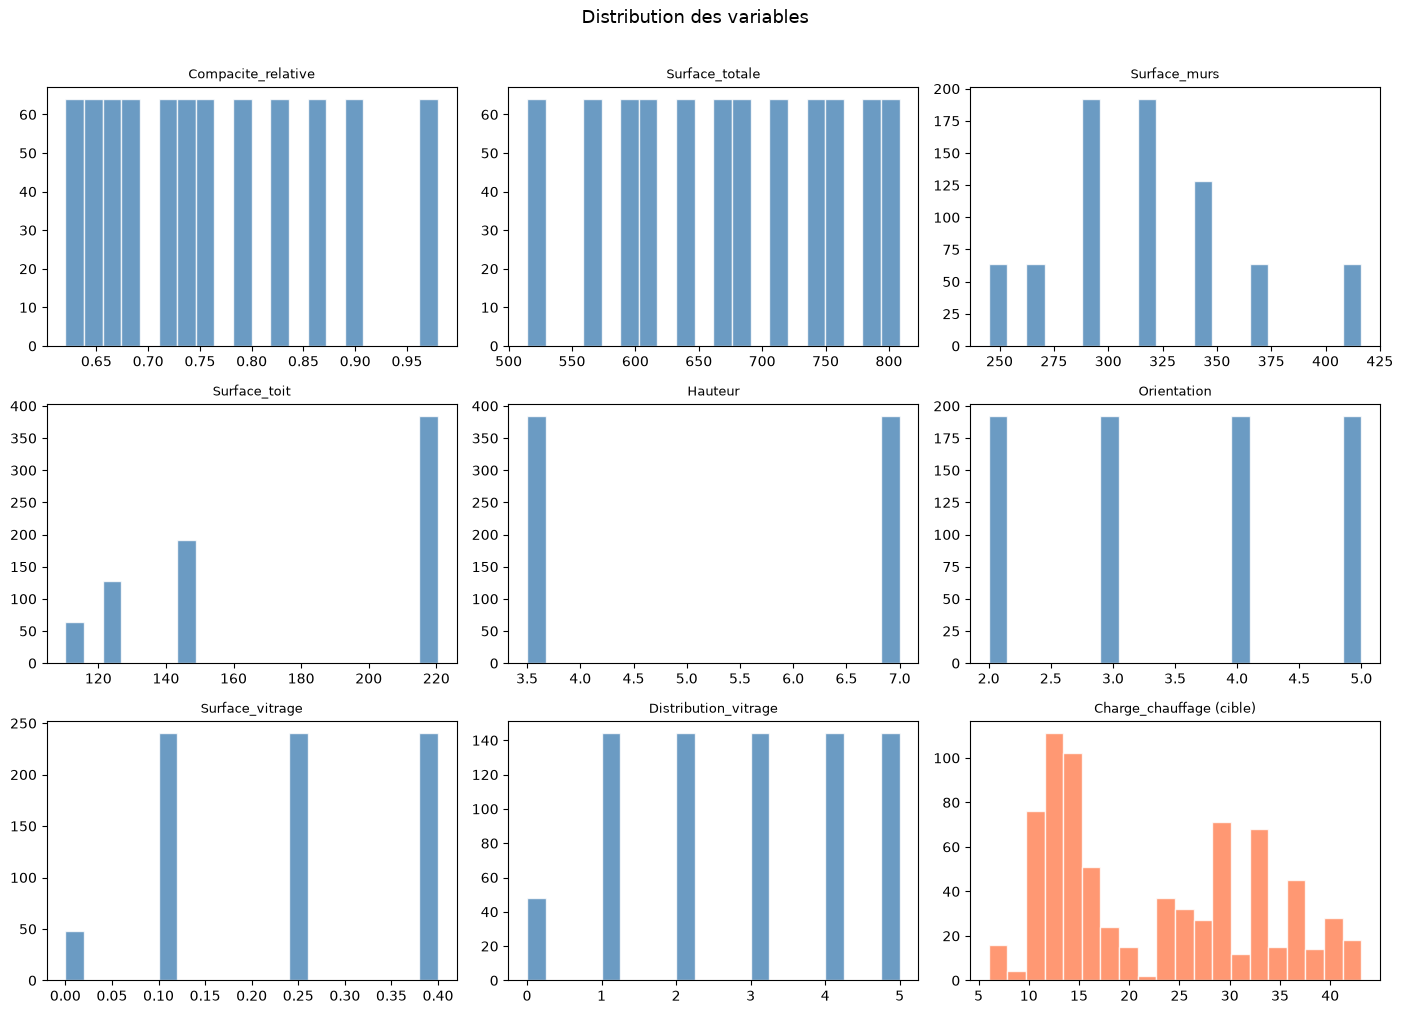

Figure sauvegardée : distributions.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    axes[i].hist(X[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

axes[8].hist(y_heating, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[8].set_title('Charge_chauffage (cible)', fontsize=9)

plt.suptitle('Distribution des variables', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : distributions.png')

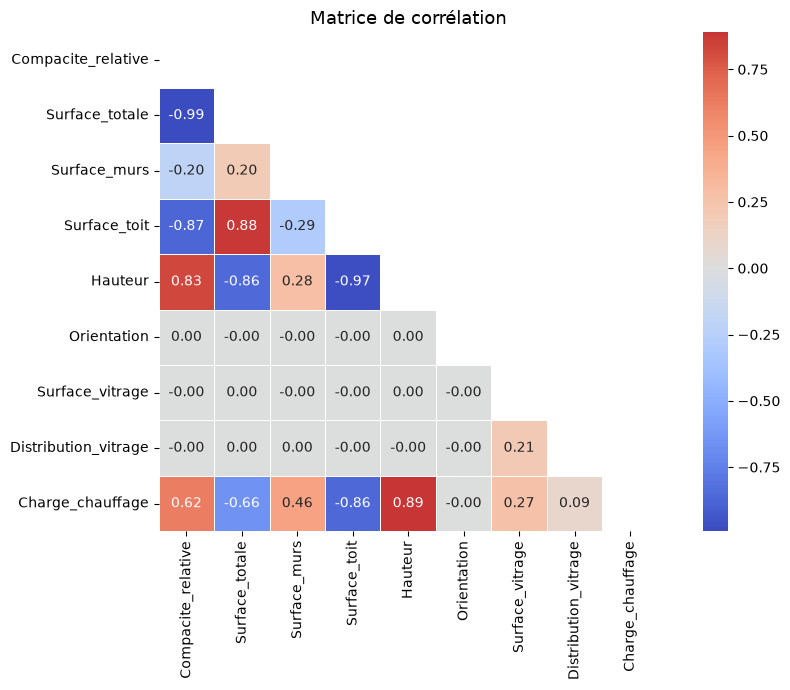

Figure sauvegardée : correlations.png


In [7]:
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation', fontsize=13)
plt.tight_layout()
plt.savefig('correlations.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : correlations.png')

In [8]:
# Corrélation avec la cible (triée)
corr_target = df.corr()['Charge_chauffage'].drop('Charge_chauffage').sort_values(key=abs, ascending=False)
print('Corrélation avec la charge de chauffage :')
print(corr_target.round(3))

Corrélation avec la charge de chauffage :
Hauteur                 0.889
Surface_toit           -0.862
Surface_totale         -0.658
Compacite_relative      0.622
Surface_murs            0.456
Surface_vitrage         0.270
Distribution_vitrage    0.087
Orientation            -0.003
Name: Charge_chauffage, dtype: float64


## 4. Préparation des données

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_heating, test_size=0.2, random_state=SEED
)

print(f'Train : {X_train.shape[0]} exemples')
print(f'Test  : {X_test.shape[0]} exemples')

Train : 614 exemples
Test  : 154 exemples


## 5. Entraînement et comparaison des modèles

In [10]:
models = {
    'Régression Linéaire': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=100, random_state=SEED))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=SEED))
    ]),
}

results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Cross-validation RMSE (5 folds)
    cv_rmse = np.sqrt(-cross_val_score(
        pipeline, X, y_heating,
        scoring='neg_mean_squared_error', cv=5
    ).mean())

    results.append({'Modèle': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'CV-RMSE': cv_rmse})
    print(f'{name:25s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}  CV-RMSE={cv_rmse:.3f}')

results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df.round(4))

Régression Linéaire        RMSE=3.025  MAE=2.182  R²=0.9122  CV-RMSE=3.200


Random Forest              RMSE=0.493  MAE=0.354  R²=0.9977  CV-RMSE=1.701


Gradient Boosting          RMSE=0.515  MAE=0.386  R²=0.9975  CV-RMSE=1.772


,Modèle,RMSE,MAE,R²,CV-RMSE
1,Random Forest,0.4934,0.3540,0.9977,1.7007
2,Gradient Boosting,0.5151,0.3862,0.9975,1.7720
0,Régression Linéaire,3.0254,2.1820,0.9122,3.1998


## 6. Analyse du meilleur modèle

In [11]:
best_name = results_df.iloc[0]['Modèle']
best_model = models[best_name]
print(f'Meilleur modèle : {best_name}')
print(f'RMSE  : {results_df.iloc[0]["RMSE"]:.3f} kWh/m²')
print(f'R²    : {results_df.iloc[0]["R²"]:.4f}')

Meilleur modèle : Random Forest
RMSE  : 0.493 kWh/m²
R²    : 0.9977


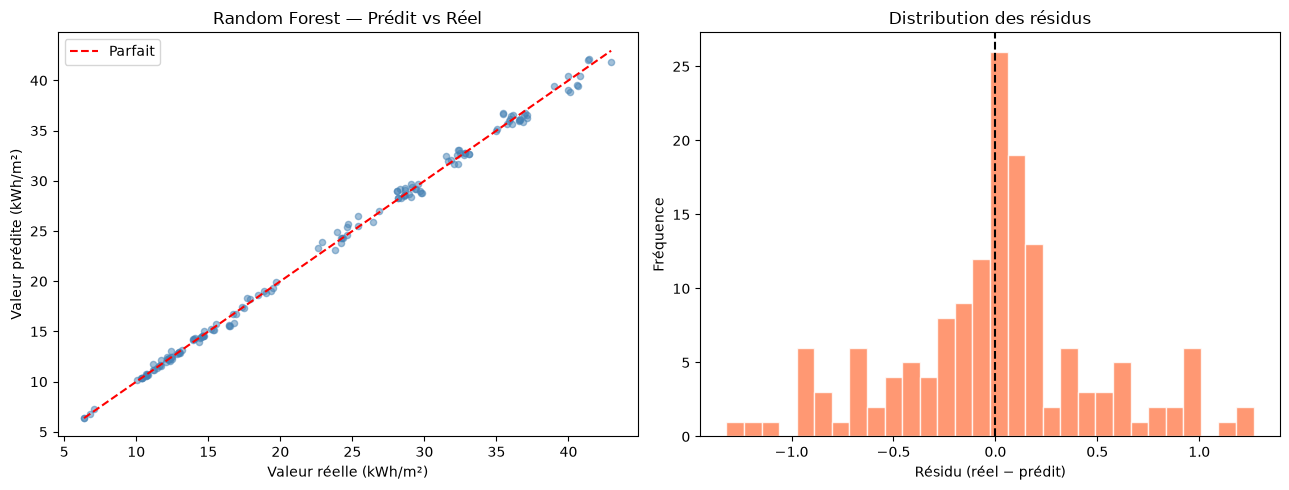

Figure sauvegardée : evaluation.png


In [12]:
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Prédit vs Réel
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
axes[0].set_xlabel('Valeur réelle (kWh/m²)')
axes[0].set_ylabel('Valeur prédite (kWh/m²)')
axes[0].set_title(f'{best_name} — Prédit vs Réel')
axes[0].legend()

# Distribution des résidus
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Résidu (réel − prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : evaluation.png')

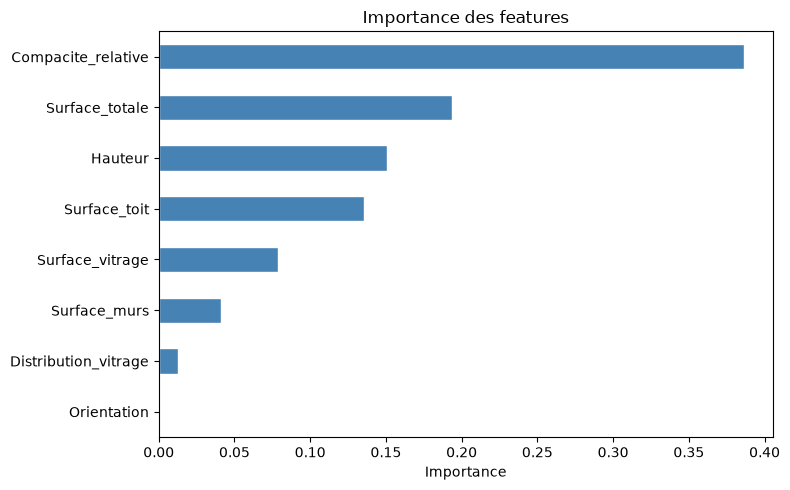

Figure sauvegardée : feature_importance.png


In [13]:
# Importance des features (si disponible)
inner = best_model.named_steps['model']
if hasattr(inner, 'feature_importances_'):
    importances = pd.Series(inner.feature_importances_, index=feature_names).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Importance des features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Figure sauvegardée : feature_importance.png')
else:
    print('Feature importances non disponibles pour ce modèle.')

## 7. Sauvegarde du modèle

In [14]:
# Réentraîner sur 100 % des données avant de sauvegarder
best_model.fit(X, y_heating)

model_dir = Path('../backend/models')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'model.pkl'
joblib.dump(best_model, model_path)
print(f'Modèle sauvegardé : {model_path.resolve()}')
print(f'Taille            : {model_path.stat().st_size / 1024:.1f} KB')

Modèle sauvegardé : /home/rakine/cloud/2ie-projet-cloud-template/backend/models/model.pkl
Taille            : 6712.3 KB


## 8. Test de prédiction (smoke test)

In [15]:
model_loaded = joblib.load(model_path)

# Exemple : bâtiment compact, grande surface, hauteur moyenne
exemple = pd.DataFrame([{
    'Compacite_relative': 0.98,
    'Surface_totale': 514.5,
    'Surface_murs': 294.0,
    'Surface_toit': 110.25,
    'Hauteur': 7.0,
    'Orientation': 2,
    'Surface_vitrage': 0.0,
    'Distribution_vitrage': 0
}])

prediction = model_loaded.predict(exemple)[0]
print(f'Charge de chauffage prédite : {prediction:.2f} kWh/m²')
assert 5 < prediction < 50, f'Valeur hors plage attendue : {prediction}'
print('Smoke test OK')

Charge de chauffage prédite : 15.73 kWh/m²
Smoke test OK


## 9. Résumé final

In [16]:
print('=== RÉSUMÉ ===')
print(f'Dataset         : UCI Energy Efficiency — {len(X)} exemples, {len(feature_names)} features')
print(f'Cible           : Charge de chauffage (kWh/m²)')
print(f'Meilleur modèle : {best_name}')
print(f'RMSE (test)     : {results_df.iloc[0]["RMSE"]:.3f}')
print(f'R²   (test)     : {results_df.iloc[0]["R²"]:.4f}')
print(f'CV-RMSE (5-fold): {results_df.iloc[0]["CV-RMSE"]:.3f}')
print(f'Modèle sauvegardé dans : backend/models/model.pkl')

=== RÉSUMÉ ===
Dataset         : UCI Energy Efficiency — 768 exemples, 8 features
Cible           : Charge de chauffage (kWh/m²)
Meilleur modèle : Random Forest
RMSE (test)     : 0.493
R²   (test)     : 0.9977
CV-RMSE (5-fold): 1.701
Modèle sauvegardé dans : backend/models/model.pkl
